<a href="https://colab.research.google.com/github/jsak737/ML_LAB/blob/main/ML_WEEK_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("/content/iris (1) (1).csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

y_pred_linear = model_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix (Linear):\n", confusion_matrix(y_test, y_pred_linear))


model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

y_pred_rbf = model_rbf.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix (RBF):\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 1.0
Confusion Matrix (Linear):
 [[ 7  0  0]
 [ 0 13  0]
 [ 0  0 10]]

RBF Kernel Accuracy: 0.9666666666666667
Confusion Matrix (RBF):
 [[ 7  0  0]
 [ 0 12  1]
 [ 0  0 10]]


Accuracy: 0.926
Confusion Matrix:
 [[172   0   0   0   0   0   0   0   0   0   2   0   0   0   0   2   0   0
    0   0   0   1   0   0   3   0]
 [  0 150   2   0   0   1   0   0   3   0   0   0   0   2   2   0   0   0
    1   0   0   0   0   0   0   0]
 [  0   0 125   4   0   0   4   0   0   0   0   0   1   0   0   3   0   0
    0   0   0   0   0   1   0   0]
 [  0   0   3 156   0   0   1   0   0   0   0   5   3   0   0   2   1   0
    0   0   0   0   0   0   0   0]
 [  0   0   2   0 138   0   0   1   0   0   0   0   1   1   0   0   1   0
    0   0   0   0   2   0   1   0]
 [  0   0   0   0   0 148   2   0   0   0   0   0   1   2   0   0   0   0
    0   1   0   0   0   0   0   0]
 [  1   0   3   0   1   0 129   0   0   0   1   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 142   0   1   0   0   0   0   1   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   1   0   5   0   0 132   0   0   1   0   0   0   0   0   0
    0   0   0   0  

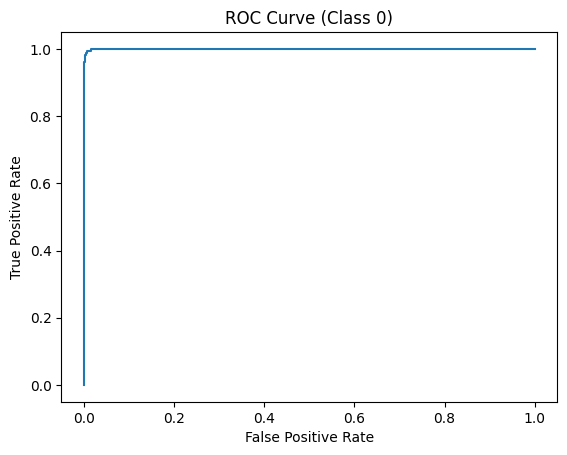

AUC Score: 0.9996335078534032


In [ ]:



import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/letter-recognition.csv")

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

y = pd.factorize(y)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes);

y_score = model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0)")
plt.show()

print("AUC Score:", roc_auc)